In [1]:
pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 7.3 MB/s eta 0:00:06
   -- ------------------------------------- 2.4/40.2 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 3.7/40.2 MB 6.6 MB/s eta 0:00:06
   ---- ----------------------------------- 5.0/40.2 MB 6.4 MB/s eta 0:00:06
   ------ --------------------------------- 6.3/40.2 MB 6.4 MB/s eta 0:00:06
   ------- -------------------------------- 7.9/40.2 MB 6.4 MB/s eta 0:00:06
   --------- ------------------------------ 9.2/40.2 MB 6.4 MB/s eta 0:00:05
   ---------- ----------------------------- 10.5/40.2 MB 6.4 MB/s eta 0:00:05
   ----------- ---------------------------- 11.8/40.2 MB 6.4 MB/s eta 0:00:05
   ------------- -------------------------- 13.1/40.2 MB 6.4 MB/s eta 0:00:05
   -------------- ------------------------- 14.4/40.2 MB 6.3 MB/s eta 0:00:05
   --------------- ------------------------ 16.0/40.2 MB 6.4 MB/s eta 0:00:04
 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Select Transformation:
1. Translation
2. Rotation
3. Scaling
4. Shearing



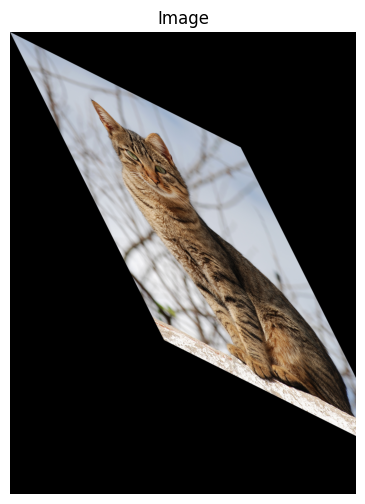

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# helper for displaying images inside a local notebook/session

def show_image(img, title='Image'):
    # convert BGR (OpenCV default) to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')

class GeometricTransformer:
    def __init__(self, image_path):
        self.image = cv2.imread(image_path)
        if self.image is None:
            raise ValueError(f"Error: Could not load image at {image_path}")
        self.h, self.w = self.image.shape[:2]

    def translate(self, tx, ty):
        """Shift image by tx, ty pixels."""
        matrix = np.float32([[1, 0, tx], [0, 1, ty]])
        return cv2.warpAffine(self.image, matrix, (self.w, self.h))

    def rotate(self, angle):
        """Rotate image around the center by a given angle."""
        center = (self.w // 2, self.h // 2)
        matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(self.image, matrix, (self.w, self.h))

    def scale(self, sx, sy):
        """Scale image by factors sx and sy."""
        return cv2.resize(self.image, None, fx=sx, fy=sy, interpolation=cv2.INTER_LINEAR)

    def shear(self, sh_x, sh_y):
        """Apply shearing (skewing) to the image."""
        matrix = np.float32([[1, sh_x, 0], [sh_y, 1, 0]])
        return cv2.warpAffine(self.image, matrix, (int(self.w * 1.5), int(self.h * 1.5)))

def run_transformation_tool():

    path = r"C:\Users\HP\GitHub\CV_Geo\ComputerVision_geotrans\Cat_November_2010-1a.jpg"
    
    tool = GeometricTransformer(path)
    

    print("\nSelect Transformation:")
    print("1. Translation\n2. Rotation\n3. Scaling\n4. Shearing\n")
    choice = input("Enter choice (1-4): ")

    result = None

    if choice == '1':
        tx = float(input("Enter x shift (pixels): "))
        ty = float(input("Enter y shift (pixels): "))
        result = tool.translate(tx, ty)
    elif choice == '2':
        angle = float(input("Enter rotation angle (degrees): "))
        result = tool.rotate(angle)
    elif choice == '3':
        sx = float(input("Enter x scale factor (e.g., 1.5): "))
        sy = float(input("Enter y scale factor (e.g., 1.5): "))
        result = tool.scale(sx, sy)
    elif choice == '4':
        shx = float(input("Enter x shear factor (e.g., 0.2): "))
        shy = float(input("Enter y shear factor (e.g., 0.2): "))
        result = tool.shear(shx, shy)
    else:
        print("Invalid choice.")
        return

    if result is not None:
        show_image(result)

if __name__ == "__main__":
    run_transformation_tool()